## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [1]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "r2": run.data.metrics.get("r2"),
                "parametros": run.data.params,
                "feature_sampled": run.data.tags.get("feature_sample"),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("rmse", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [35]:
def _log_feature_history(X, run_name=None):
    """Registra histórico de features no MLflow para o run atual."""
    try:
        cols = list(X.columns) if hasattr(X, "columns") else []
        mlflow.set_tag("feature_history_run_name", run_name or "")
        mlflow.set_tag("feature_history_num_columns", len(cols))
        if cols:
            mlflow.set_tag("feature_history_columns", ",".join(cols[:50]))
            if len(cols) > 50:
                mlflow.set_tag("feature_history_columns_truncated", "true")

            feature_history_path = Path(tempfile.mkdtemp()) / "feature_history.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_history_path, index=False)
            mlflow.log_artifact(str(feature_history_path), artifact_path="feature_history")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature history: {exc}")


def _log_feature_store(
    X,
    run_name,
    feature_group_name,
    description,
    source,
    ):
    """Registra metadados de feature store no MLflow para o run atual."""
    try:
        mlflow.set_tag("feature_store_run_name", run_name or "")
        mlflow.set_tag("feature_store_group_name", feature_group_name)
        mlflow.set_tag("feature_store_description", description)
        mlflow.set_tag("feature_store_source", source)
        mlflow.set_tag("feature_store_num_columns", X.shape[1] if hasattr(X, "shape") else None)

        cols = list(X.columns) if hasattr(X, "columns") else []
        if cols:
            feature_store_path = Path(tempfile.mkdtemp()) / "feature_store.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_store_path, index=False)
            mlflow.log_artifact(str(feature_store_path), artifact_path="feature_store")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature store: {exc}")


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn, fit_kwargs=None):
    """Treina um pipeline com logging automático de métricas e parâmetros no MLflow."""
    mlflow.start_run(run_name=nome)
    is_keras_model = hasattr(estimador, "save") and not hasattr(estimador, "get_params")
    mlflow.set_tag("modelo_tipo", "keras" if is_keras_model else "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    if callable(criar_preprocessador_fn):
        preprocessor = criar_preprocessador_fn()
    else:
        preprocessor = criar_preprocessador_fn

    if preprocessor is None:
        raise ValueError("`criar_preprocessador_fn` deve retornar um preprocessor ou receber um objeto transformador.")

    try:
        if is_keras_model:
            X_tr_pre = preprocessor.fit_transform(X_tr)
            X_te_pre = preprocessor.transform(X_te)
            fit_kwargs = fit_kwargs or {}
            estimador.fit(X_tr_pre, y_tr, validation_data=(X_te_pre, y_te), verbose=0, **fit_kwargs)
            pred = estimador.predict(X_te_pre).ravel()
            mlflow.keras.log_model(estimador, artifact_path=nome)

            preprocessor_path = Path(tempfile.mkdtemp()) / "preprocessor.joblib"
            joblib.dump(preprocessor, preprocessor_path)
            mlflow.log_artifact(str(preprocessor_path), artifact_path=nome)
            trained_model = estimador
        else:
            pipe = Pipeline([
                ("preprocessador", preprocessor),
                ("modelo", estimador),
            ])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            mlflow.sklearn.log_model(pipe, name=nome)
            trained_model = pipe

            if hasattr(estimador, "get_params"):
                params = estimador.get_params()
                for k, v in list(params.items())[:20]:
                    v_str = str(v)[:100] if v is not None else "None"
                    mlflow.log_param(f"modelo__{k}", v_str)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return trained_model, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()
        


def _build_keras_from_trial(trial, input_dim):
    """Reconstrói um modelo Keras a partir dos parâmetros de um trial Optuna."""
    def _trial_param(name):
        params = getattr(trial, "_params", None) or getattr(trial, "params", None) or {}
        return params.get(name, None)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    num_camadas = _trial_param("num_camadas")
    if num_camadas is None:
        num_camadas = trial.suggest_int("num_camadas", 1, 4)

    for i in range(num_camadas):
        unidades = _trial_param(f"unidades_{i}")
        if unidades is None:
            unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)

        dropout = _trial_param(f"dropout_{i}")
        if dropout is None:
            dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)

        model.add(layers.Dense(int(unidades), activation="relu"))
        if dropout and float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1))
    lr = _trial_param("learning_rate")
    if lr is None:
        lr = trial.suggest_categorical("learning_rate", [1e-2, 1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [3]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [4]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()
keras.utils.set_random_seed(42)

# ===== Configuração MLflow =====
EXPERIMENTO_NOME = "preco-imoveis-joinville"
RUNS_PARENT_DIR = Path.cwd().parent / "mlruns"
RUNS_PARENT_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"file:///{RUNS_PARENT_DIR}")
mlflow.set_experiment(EXPERIMENTO_NOME)
print(f"MLflow experiment: {EXPERIMENTO_NOME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")

if DATABRICKS_HOST and DATABRICKS_TOKEN:
    os.environ["DATABRICKS_HOST"] = DATABRICKS_HOST
    os.environ["DATABRICKS_TOKEN"] = DATABRICKS_TOKEN
    mlflow.set_tracking_uri("databricks")
    mlflow.set_experiment("/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville")
    print("Using Databricks tracking URI with DATABRICKS_HOST and DATABRICKS_TOKEN.")
    print("Databricks host: {}".format(DATABRICKS_HOST))
elif DATABRICKS_CONFIG_PROFILE:
    os.environ["DATABRICKS_CONFIG_PROFILE"] = DATABRICKS_CONFIG_PROFILE
    mlflow.set_tracking_uri("databricks")
    mlflow.set_experiment("/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville")
    print("Using Databricks tracking URI with profile {}.".format(DATABRICKS_CONFIG_PROFILE))
else:
    print("Databricks authentication not configured; continuing with local MLflow tracking.")
    print("Set DATABRICKS_HOST and DATABRICKS_TOKEN, or DATABRICKS_CONFIG_PROFILE, before rerunning.")


Traceback (most recent call last):
  File "c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\mlflow\store\trac

MLflow experiment: preco-imoveis-joinville
Tracking URI: file:///c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\mlruns
Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 
Using Databricks tracking URI with DATABRICKS_HOST and DATABRICKS_TOKEN.
Databricks host: https://dbc-ed602b14-1f14.cloud.databricks.com


## Carregar dados

In [5]:


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / "joinville"
pd_joinville = pd.read_parquet(PASTA_DADOS / f'joinville_com_ind_local_2026-05.parquet')

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [6]:
import osmnx as ox

cidade = "Joinville, Santa Catarina, Brasil"

#-----------------------------------------------------
tags_hospitais = {"amenity": "hospital"}

hospitais = ox.features_from_place(cidade, tags_hospitais)
#----------------------------------------------------------

mercados = ox.features_from_place(
    cidade,
    {"shop": ["supermarket", "convenience"]}
)

#---------------------------------------------------------
farmacias = ox.features_from_place(
    cidade,
    {"amenity": "pharmacy"}
)

parques = ox.features_from_place(
    cidade,
    tags={
        "leisure": ["park", "garden"],
        "landuse": "recreation_ground"
    }
)

escolas = ox.features_from_place(
    cidade,
    tags={
        "amenity": ["school", "college", "university"]
    }
)

policia = ox.features_from_place(
    cidade,
    tags={
        "amenity": ["police", "fire_station", "courthouse"]
    }
)

In [7]:
escolas["geometry_std"] = escolas.geometry.apply(
    lambda g: g.centroid if g.geom_type != "Point" else g
)

escolas_std = escolas.set_geometry("geometry_std")
escolas_std.geometry.geom_type.value_counts()

Point    186
Name: count, dtype: int64

In [8]:
import re
import pandas as pd

def classificar_escola(row):
    nome = str(row.get("name", "")).lower()

    padroes_publicos = [
        "municipal",
        "estadual",
        "federal",
        "instituto federal",
        "colégio estadual",
        "escola municipal",
        "cmei", "emei", "emef", "eef", "eeef",
        "universidade federal",
        "universidade estadual",
        "ifpr", "ifsp", "ifsc", "ifrs"
    ]

    for p in padroes_publicos:
        if p in nome:
            return "publica"

    return "privada"

escolas_std["tipo_escola"] = escolas_std.apply(classificar_escola, axis=1)

In [9]:
from shapely import wkt

def extract_lat_lon_from_geometry(df, geometry_col="geometry"):
    """
    Extrai lat/lon de geometrias POINT ou POLYGON usando centróide
    """
    def get_lat_lon(geom_wkt):
        try:
            geom = wkt.loads(geom_wkt)

            # Para POINT, POLYGON, MULTIPOLYGON, etc
            point = geom.centroid

            return pd.Series({
                "lat": point.y,
                "lon": point.x
            })
        except:
            return pd.Series({
                "lat": None,
                "lon": None
            })

    coords = df[geometry_col].apply(get_lat_lon)
    df = pd.concat([df, coords], axis=1)

    return df

import geopandas as gpd

def extrair_coordenadas(gdf, geometry_std=False):
    # .centroid encontra o centro de massa se for POLYGON, e mantém o ponto se for POINT

    if geometry_std and "geometry_std" in gdf.columns:
        centroids = gdf['geometry_std'].centroid
    else:
        centroids = gdf['geometry'].centroid

    # Extrai x (lon) e y (lat) com segurança
    gdf['lon'] = centroids.x
    gdf['lat'] = centroids.y
    
    return gdf



In [10]:
escolas_publicas = escolas_std[escolas_std["tipo_escola"] == "publica"].copy()
escolas_privadas = escolas_std[escolas_std["tipo_escola"] == "privada"].copy()

In [11]:
escolas_publicas = extrair_coordenadas(escolas_publicas, geometry_std=True)
escolas_privadas = extrair_coordenadas(escolas_privadas, geometry_std=True)
hospitais = extrair_coordenadas(hospitais)
parques = extrair_coordenadas(parques)
farmacias = extrair_coordenadas(farmacias)
mercados = extrair_coordenadas(mercados)
policia = extrair_coordenadas(policia)

In [12]:
pois = {
    "escolas_publicas": escolas_publicas,
    "escolas_privadas": escolas_privadas,
    "hospitais": hospitais,
    "parques": parques,
    "farmacia": farmacias,
    "mercado": mercados,
    "policia": policia
}

for nome, df_poi in pois.items():
    if not {"lat", "lon"}.issubset(df_poi.columns):
        pois[nome] = extract_lat_lon_from_geometry(df_poi)

In [13]:
from sklearn.neighbors import BallTree
def add_poi_features(
    imoveis_df,
    poi_df,
    prefix,
    radius_metros=[]
):
    """
    prefix: nome da categoria (ex: 'escola', 'hospital')
    radius_metros: lista de raios em metros para contagem
    """

    # Converter para radianos
    imoveis_coords = np.radians(imoveis_df[["lat", "lng"]].values)
    poi_coords = np.radians(poi_df[["lat", "lon"]].values)

    # Construir árvore
    tree = BallTree(poi_coords, metric="haversine")

    # Distância mínima
    dist, _ = tree.query(imoveis_coords, k=1)
    imoveis_df[f"dist_{prefix}_mais_proximo"] = dist[:, 0] * 6371000  # metros

    # Contagem por raio
    for r in radius_metros:
        count = tree.query_radius(
            imoveis_coords,
            r=r / 6371000,
            count_only=True
        )
        imoveis_df[f"qtd_{prefix}_{r}m"] = count

    return imoveis_df

In [14]:
from sklearn.neighbors import BallTree
import numpy as np

def add_poi_features(
    imoveis_df,
    poi_df,
    prefix,
    radius_metros=[]
):
    """
    prefix: nome da categoria (ex: 'escola', 'hospital')
    radius_metros: lista de raios em metros para contagem
    """
    # 1. BLINDAGEM: Remove linhas onde as coordenadas cruciais sejam NaN
    # Remove nulos dos POIs (essencial para a árvore não quebrar)
    poi_limpo = poi_df.dropna(subset=["lat", "lon"])
    
    # Se o DataFrame de POIs ficar vazio após o drop, interrompe para não quebrar a árvore
    if poi_limpo.empty:
        print(f"⚠️ Aviso: Nenhum POI válido encontrado para o prefixo '{prefix}'. Preenchendo com valores padrão.")
        imoveis_df[f"dist_{prefix}_mais_proximo"] = np.nan
        for r in radius_metros:
            imoveis_df[f"qtd_{prefix}_{r}m"] = 0
        return imoveis_df

    # Remove nulos dos imóveis (caso algum anúncio tenha vindo sem Lat/Lng do scraping)
    # Se houver NaNs aqui, preenchemos temporariamente com 0 para a query rodar, e depois restauramos
    imoveis_limpo_coords = imoveis_df[["lat", "lng"]].fillna(0)

    # 2. Converter para radianos (usando os DataFrames limpos)
    imoveis_coords = np.radians(imoveis_limpo_coords.values)
    poi_coords = np.radians(poi_limpo[["lat", "lon"]].values)

    # 3. Construir árvore
    tree = BallTree(poi_coords, metric="haversine")

    # 4. Distância mínima
    dist, _ = tree.query(imoveis_coords, k=1)
    imoveis_df[f"dist_{prefix}_mais_proximo"] = dist[:, 0] * 6371000  # metros

    # 5. Contagem por raio
    for r in radius_metros:
        count = tree.query_radius(
            imoveis_coords,
            r=r / 6371000,
            count_only=True
        )
        imoveis_df[f"qtd_{prefix}_{r}m"] = count

    # 6. Se o imóvel original tinha Lat/Lng nulo, limpamos as colunas geradas por ele
    nulo_mask = imoveis_df["lat"].isna() | imoveis_df["lng"].isna()
    if nulo_mask.any():
        imoveis_df.loc[nulo_mask, f"dist_{prefix}_mais_proximo"] = np.nan
        for r in radius_metros:
            imoveis_df.loc[nulo_mask, f"qtd_{prefix}_{r}m"] = 0

    return imoveis_df

In [15]:
pd_joinville = add_poi_features(
    pd_joinville,
    escolas_privadas,
    prefix="escolas_privadas",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    escolas_publicas,
    prefix="escolas_publicas",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    policia,
    prefix="policia",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    hospitais,
    prefix="hospital",
    radius_metros=[1000]
)

pd_joinville = add_poi_features(
    pd_joinville,
    mercados,
    prefix="mercado",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    farmacias,
    prefix="farmacia",
    radius_metros=[300]
)

pd_joinville = add_poi_features(
    pd_joinville,
    parques,
    prefix="parque",
    radius_metros=[1000]
)

In [16]:
import numpy as np

pd_joinville['score_escola_privada'] = (
    1.2 * np.exp(-pd_joinville['dist_escolas_privadas_mais_proximo'] / 600) +
    0.6 * pd_joinville['qtd_escolas_privadas_500m']
)

pd_joinville['score_escola_publica'] = (
    0.6 * np.exp(-pd_joinville['dist_escolas_publicas_mais_proximo'] / 600) +
    0.2 * pd_joinville['qtd_escolas_publicas_500m']
)


pd_joinville['score_hospitais'] = (
    0.8 * np.exp(-pd_joinville['dist_hospital_mais_proximo'] / 1200) +
    0.4 * pd_joinville['qtd_hospital_1000m']
)


pd_joinville['score_mercado'] = (
    1.0 * np.exp(-pd_joinville['dist_mercado_mais_proximo'] / 400) +
    0.4 * pd_joinville['qtd_mercado_500m']
)


pd_joinville['score_farmacia'] = (
    0.6 * np.exp(-pd_joinville['dist_farmacia_mais_proximo'] / 300) +
    0.2 * pd_joinville['qtd_farmacia_300m']
)


pd_joinville['score_parque'] = (
    1.2 * np.exp(-pd_joinville['dist_parque_mais_proximo'] / 1200) +
    0.8 * pd_joinville['qtd_parque_1000m']
)


pd_joinville['score_seguranca'] = (
    1.0 * np.exp(-pd_joinville['dist_policia_mais_proximo'] / 1500) +
    0.3 * pd_joinville['qtd_policia_500m']
)

pd_joinville['score_educacao'] = (
    pd_joinville['score_escola_privada']
    - 0.2 * pd_joinville['score_escola_publica']
)


In [17]:
pd_joinville.drop(columns=[
            "score",
            "dist_escolas_privadas_mais_proximo",
            "qtd_escolas_privadas_500m",
            "dist_escolas_publicas_mais_proximo",
            "qtd_escolas_publicas_500m",
            "dist_hospital_mais_proximo",
            "qtd_policia_500m","dist_hospital_mais_proximo",
            "qtd_hospital_1000m","dist_mercado_mais_proximo",
            "qtd_mercado_500m","dist_farmacia_mais_proximo",
            "qtd_farmacia_300m","dist_parque_mais_proximo",
            "qtd_parque_1000m", "dist_policia_mais_proximo",
            
        ], inplace=True)

## Pré-processamento e features

In [18]:
#TARGET = "valor_imovel"
TARGET = "preco_por_m2"

NUMERIC_FEATURES = [
    #"metragem", 
    "banheiros", 
    "vagas", 
    "quartos",
    #"condominio", "iptu", 
    #"lat", "lng", "p25_bairro", "p50_bairro", "p75_bairro", 
    #"score",
    "score_escola_privada",
    "score_escola_publica",
    "score_hospitais",
    "score_mercado",
    "score_farmacia",
    "score_parque",
    "score_seguranca",
    "score_educacao"
]
CATEGORICAL_FEATURES = ["tipo_imovel", 
                        "bairro", 
                        #"fonte"
                        ]

# Colunas derivadas do preço — não entram no modelo (data leakage)
COLUNAS_LEAKAGE = [
    #"preco_por_m2", 
    "valor_imovel",
    "metragem",
    "desvio_mediana", 
    "faixa"]

df_modelo = pd_joinville.copy()
df_modelo = df_modelo.dropna(subset=[TARGET, "metragem"])
df_modelo = df_modelo[
    (df_modelo["metragem"] > 10)
    #& (df_modelo[TARGET] >= 50_000)
    #& (df_modelo[TARGET] <= 25_000_000)
    & ((df_modelo["tipo_imovel"] == "casa") | (df_modelo["preco_por_m2"] >= 100))
    & ((df_modelo["tipo_imovel"] == "apartamento") | (df_modelo["preco_por_m2"] >= 100))
].copy()

X = df_modelo[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_modelo[TARGET]

X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.4, random_state=42
)

print(f"Amostras para treino: {len(X_train):,} | teste: {len(X_test):,} | validação: {len(X_val):,}")

Amostras para treino: 19,923 | teste: 2,657 | validação: 3,985


In [19]:
def _replace_inf(X):
    return np.nan_to_num(
        np.asarray(X, dtype=np.float64),
        nan=np.nan,
        posinf=np.nan,
        neginf=np.nan,
    )


def criar_preprocessador():
    numeric_pipe = Pipeline([
        (
            "replace_inf",
            FunctionTransformer(
                _replace_inf,
                validate=False,
                feature_names_out="one-to-one",
            ),
        ),
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def metricas(nome, y_true, y_pred):

    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}


def treinar_pipeline(nome, estimador, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ("preprocessador", 
         ),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return pipe, metricas(nome, y_te, pred)





## Otimização de hiperparâmetros (Optuna)

Busca os melhores hiperparâmetros com **validação cruzada (3 folds)** no conjunto de treino, minimizando RMSE. Ajuste `N_TRIALS` para mais/menos precisão (mais trials = mais lento).

In [20]:
N_TRIALS = 40
N_FOLDS = 3
RANDOM_STATE = 42

from sklearn.model_selection import cross_validate  # <-- Certifique-se de importar este cara

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
melhores_hiperparametros_modelos = {}
estudos_optuna = {}


def otimizar_modelo(nome, factory):
    """factory(trial) -> estimador sklearn/catboost/lightgbm"""

    def objective(trial):
        modelo = factory(trial)
        pipe = Pipeline([
            ("preprocessador", criar_preprocessador()),
            ("modelo", modelo),
        ])
        
        scoring_metrics = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    }
        
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring_metrics,
            n_jobs=-1,
        )
        
        #rmse_cv = -scores.mean()
        rmse_cv = -scores["test_rmse"].mean()
        mae_cv  = -scores["test_mae"].mean()
        mape_cv = -scores["test_mape"].mean()
        r2_cv   = scores["test_r2"].mean()

        with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
            mlflow.set_tag("modelo", nome)
            mlflow.set_tag("trial", trial.number)
            for param_name, param_value in trial.params.items():
                mlflow.log_param(param_name, str(param_value)[:100])
            mlflow.log_metric("rmse", rmse_cv)
            mlflow.log_metric("mae", mae_cv)
            mlflow.log_metric("mape", mape_cv)
            mlflow.log_metric("r2", r2_cv)
            _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")
            _log_feature_history(X_train, run_name=f"optuna_{nome}")


        return rmse_cv

    with mlflow.start_run(run_name=f"optuna_{nome}"):
        mlflow.set_tag("otimizacao", "optuna")
        mlflow.set_tag("modelo", nome)
        mlflow.log_param("n_trials", N_TRIALS)
        mlflow.log_param("n_folds", N_FOLDS)
        _log_feature_history(X_train, run_name=f"optuna_{nome}")
        _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")

        study = optuna.create_study(
            direction="minimize",
            study_name=nome,
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

        melhores_hiperparametros_modelos[nome] = study.best_params
        estudos_optuna[nome] = study

        for param_name, param_value in study.best_params.items():
            mlflow.log_param(f"best_{param_name}", str(param_value)[:100])
        mlflow.log_metric("best_rmse", study.best_value)

    print(f"{nome}: melhor RMSE CV = {study.best_value:,.2f} | params = {study.best_params}")
    return study


def factory_catboost(trial):
    return CatBoostRegressor(
        iterations=trial.suggest_int("iterations", 200, 800, step=50),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )


def factory_lightgbm(trial):
    return LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def factory_random_forest(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 0.9]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def factory_hist_gb(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
    )

In [21]:
# 1. Ajustamos a sua função para aceitar o objeto 'hp' (Hyperparameters)
def construir_modelo_otimizavel(hp, input_dim):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    
    # Otimiza o número de camadas ocultas (entre 1 e 4 camadas)
    for i in range(hp.Int("num_camadas", min_value=1, max_value=4, default=3)):
        # Otimiza o número de neurônios de cada camada (entre 64 e 512, pulando de 64 em 64)
        modelo.add(
            layers.Dense(
                units=hp.Int(f"unidades_{i}", min_value=64, max_value=512, step=64),
                activation="relu"
            )
        )
        # Otimiza a taxa de Dropout (de 0.0 a 0.4, variando de 0.1 em 0.1)
        modelo.add(layers.Dropout(rate=hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.4, step=0.1)))
    
    # Camada de saída (Regressão para o preço do imóvel)
    modelo.add(layers.Dense(1))
    
    # Otimiza a taxa de aprendizado do Adam (escolha entre 1e-2, 1e-3 ou 1e-4)
    lr = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return modelo

In [22]:
print("=== Otimização Optuna (pode levar alguns minutos) ===\n")

train_keras = False  # Defina como False se quiser pular a otimização do modelo Keras (MLP)

if train_keras:
    for nome, factory in [
        ("catboost", factory_catboost),
        ("lightgbm", factory_lightgbm),
        ("random_forest", factory_random_forest),
        ("hist_gradient_boosting", factory_hist_gb),
    ]:
        otimizar_modelo(nome, factory)

    pd.DataFrame(melhores_hiperparametros_modelos).T

=== Otimização Optuna (pode levar alguns minutos) ===



In [23]:
# Mude para o número real de colunas do seu X_train

train_mlp = False  # Defina como True para rodar a otimização do MLP (pode ser demorado)

preprocessador_keras = Pipeline([
    ("preprocessador", criar_preprocessador()),
    ("fix_inf", FunctionTransformer(
        lambda X: np.nan_to_num(np.asarray(X, dtype=np.float64), nan=np.nan, posinf=np.nan, neginf=np.nan),
        validate=False,
    )),
    ("clip_extreme", FunctionTransformer(
        lambda X: np.clip(X, -1e200, 1e200),
        validate=False,
    )),
    ("scaler", StandardScaler()),
])

X_train_keras = preprocessador_keras.fit_transform(X_train)
X_test_keras = preprocessador_keras.transform(X_test)
X_val_keras = preprocessador_keras.transform(X_val)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_val_log = np.log1p(y_val)

INPUT_DIM = X_train_keras.shape[1]

if train_mlp:             
    study, best_mlp = otimizar_mlp_com_mlflow(
        n_trials=30, 
        X_train_keras=X_train_keras, 
        y_train_keras=y_train_log, 
            x_val_keras=X_val_keras,
            y_val_keras=y_val_log,
        input_dim=X_train_keras.shape[1]
    )

## Treino e avaliação (hiperparâmetros otimizados)

Modelos treinados com os melhores hiperparâmetros encontrados pelo Optuna (seção anterior):
- **Regressão linear** (baseline, sem tuning)
- **Random Forest**, **HistGradientBoosting**, **LightGBM**, **CatBoost**
- **Rede neural** (Keras MLP)

In [24]:
result = comparar_modelos_mlflow("imoveis-joinville")

Usando experimento encontrado: /Users/sehnemjeferson@gmail.com/imoveis-joinville (ID: 812916905475604)
Comparação de modelos treinados:
                       run_name          rmse          mae      mape            r2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             parametros                                                                                                       

In [25]:
from IPython.display import display

def pegando_melhores_modelos(result, modelos_esperados=None):
    # Modelos de interesse
    if modelos_esperados is not None:
        best_modelos = modelos_esperados
    else:
        best_modelos = ["keras", "random_forest", "lightgbm", "hist_gradient_boosting", "catboost"]

    # Filtra runs relevantes
    best_runs = result[result["modelo"].isin(best_modelos)].copy()
    if best_runs.empty:
        print("Nenhum run encontrado para os modelos esperados.")
    else:
        # Seleciona o run com menor RMSE por modelo
        best_idx = best_runs.groupby("modelo")["rmse"].idxmin()
        best_runs = best_runs.loc[best_idx].reset_index(drop=True)

        best_params_df = best_runs[["modelo", "run_name", "rmse", "mae", "mape", "r2", "parametros", "feature_sampled"]].copy()
        print("Melhores parâmetros por modelo:")
        display(best_params_df)

        import ast

        def _parse_params_field(p):
            # Caso os parâmetros venham como string literal
            if isinstance(p, str):
                try:
                    return ast.literal_eval(p)
                except Exception:
                    return p
            return p

        def _normalize_values(d):
            if not isinstance(d, dict):
                return d
            out = {}
            for k, v in d.items():
                if isinstance(v, str):
                    # bool
                    lv = v.lower()
                    if lv in ("true", "false"):
                        out[k] = lv == "true"
                        continue
                    # int
                    if v.isdigit():
                        out[k] = int(v)
                        continue
                    # float
                    try:
                        out[k] = float(v)
                        continue
                    except Exception:
                        out[k] = v
                else:
                    out[k] = v
            return out

        def build_model_from_params(modelo_nome, params):
            params = _parse_params_field(params)
            if isinstance(params, dict):
                params = _normalize_values(params)

            if modelo_nome == "keras":
                try:
                    trial = optuna.trial.FixedTrial(params)
                    return _build_keras_from_trial(trial, input_dim=X_train_keras.shape[1])
                except Exception as e:
                    raise RuntimeError(f"Falha ao reconstruir Keras: {e}")

            if modelo_nome == "random_forest":
                return RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)

            if modelo_nome == "lightgbm":
                return LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)

            if modelo_nome == "hist_gradient_boosting":
                return HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE)

            if modelo_nome == "catboost":
                return CatBoostRegressor(**params, random_state=RANDOM_STATE, verbose=0)

            raise ValueError(f"Modelo não suportado: {modelo_nome}")

        # Reconstrói modelos
        best_models = {}
        for _, row in best_runs.iterrows():
            nome = row["modelo"]
            params = row["parametros"]
            try:
                best_models[nome] = build_model_from_params(nome, params)
                print(f"Reconstruído: {nome}")
            except Exception as e:
                print(f"Erro reconstruindo {nome}: {e}")
        return best_models, [best_params_df['feature_sampled'].iloc[0]]


In [26]:
best_models, features = pegando_melhores_modelos(result)

Melhores parâmetros por modelo:


,modelo,run_name,rmse,mae,mape,r2,parametros,feature_sampled
0,catboost,catboost_trial_35,4169.300672,1482.364472,0.472542,0.331484,"{'depth': '10', 'iterations': '650', 'l2_leaf_...","banheiros, vagas, quartos, score_escola_privad..."
1,hist_gradient_boosting,hist_gradient_boosting_trial_18,4167.069963,1556.051857,0.527912,0.332377,"{'l2_regularization': '2.4099073111063656', 'l...","banheiros, vagas, quartos, score_escola_privad..."
2,keras,mlp_keras_trial_14,2377.910853,1521.162501,0.332705,0.483615,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad..."
3,lightgbm,lightgbm_trial_38,4149.728011,1514.210852,0.522148,0.338690,"{'colsample_bytree': '0.9024301075975578', 'le...","banheiros, vagas, quartos, score_escola_privad..."
4,random_forest,random_forest_trial_24,4122.826629,1492.239403,0.510974,0.349365,"{'max_depth': '21', 'max_features': 'sqrt', 'm...","banheiros, vagas, quartos, score_escola_privad..."


Reconstruído: catboost
Reconstruído: hist_gradient_boosting


Reconstruído: keras
Reconstruído: lightgbm
Reconstruído: random_forest


In [ ]:
metricas_dict = {}
modelos_treinados = {}
for nome, modelo in best_models.items():
    print(f"\n--- Avaliando modelo: {nome} ---")
    if nome == "keras":
        # Para Keras, usamos os dados já pré-processados e log-transformados
        nome_modelo = f"{nome}_final"
        modelo_treinado, metricas_resultado = treinar_pipeline_com_mlflow(
            nome_modelo,
            modelo,
             X_train, y_train, X_test, y_test, criar_preprocessador)
    else:
        nome_modelo = f"{nome}_final"
        modelo_treinado, metricas_resultado = treinar_pipeline_com_mlflow(nome_modelo, modelo, X_train, y_train, X_test, y_test, criar_preprocessador)

    modelos_treinados[nome] = modelo_treinado
    metricas_dict[nome] = metricas_resultado
metricas_df = pd.DataFrame(metricas_dict).T

In [28]:
metricas_df

,rmse,mae,mape,r2
catboost,2830.297645,1434.073696,43.911488,0.339576
hist_gradient_boosting,2345.588655,1495.331528,47.302742,0.546411
keras,2650.017595,1718.577697,45.493064,0.421030
lightgbm,2242.491822,1426.562261,43.773001,0.585409
random_forest,2219.190593,1387.105572,43.529155,0.593980


In [37]:
melhor_modelo = metricas_df["rmse"].idxmin()
melhor_modelo

'random_forest'

## Importância das features (SHAP)

Análise de interpretabilidade com [SHAP](https://shap.readthedocs.io/): impacto de cada variável na predição de `valor_imovel`.

Usa o melhor modelo em árvore/boosting disponível (ou o modelo vencedor, se for sklearn).

Modelo selecionado para SHAP: random_forest
Features: 49 (11 num + 38 cat)
Features: 49, amostras SHAP: 500


tipo_imovel_apartamento      507.995642
score_hospitais              349.693332
score_escola_publica         347.122099
tipo_imovel_casa             329.566394
quartos                      301.184286
tipo_imovel_terreno          290.306778
vagas                        203.876360
banheiros                    180.989762
bairro_america               162.863288
score_parque                 104.007121
score_farmacia                97.867289
score_seguranca               95.981047
score_educacao                95.501216
score_escola_privada          88.727499
bairro_gloria                 84.860216
score_mercado                 72.015560
bairro_anita garibaldi        50.889118
bairro_infrequent_sklearn     43.508119
bairro_atiradores             31.349457
bairro_santo antonio          26.416378
dtype: float64

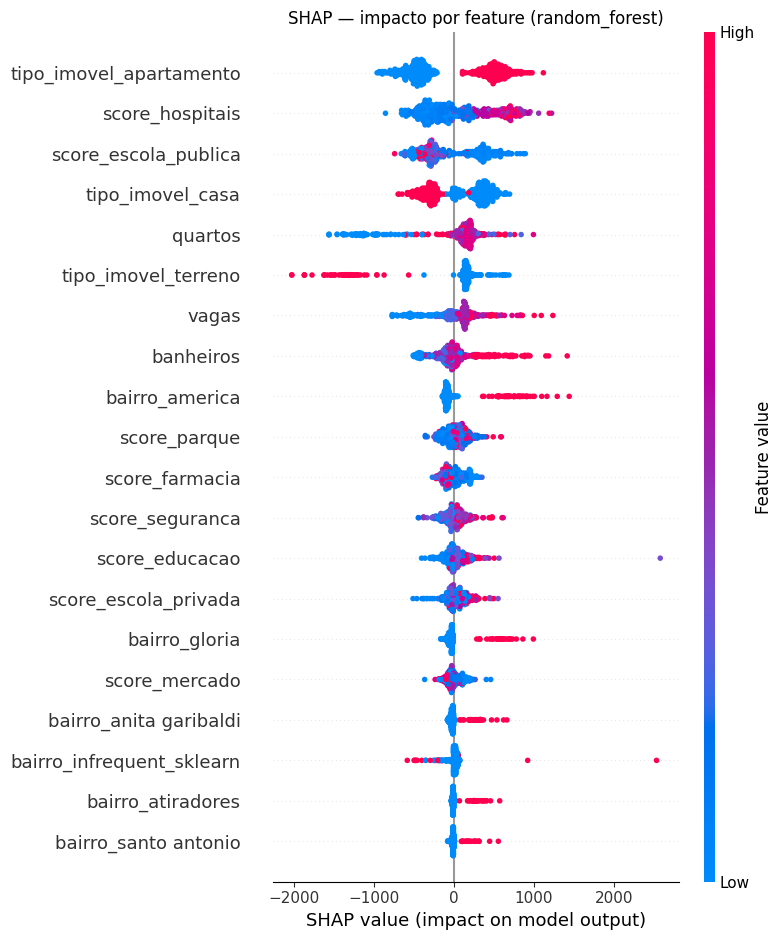

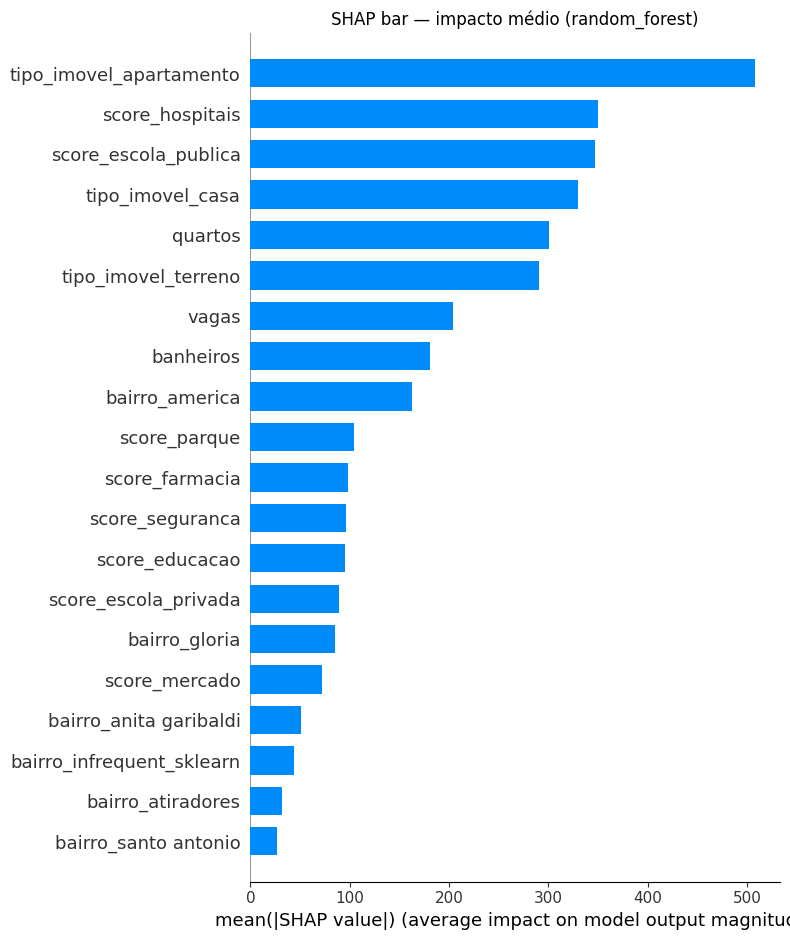

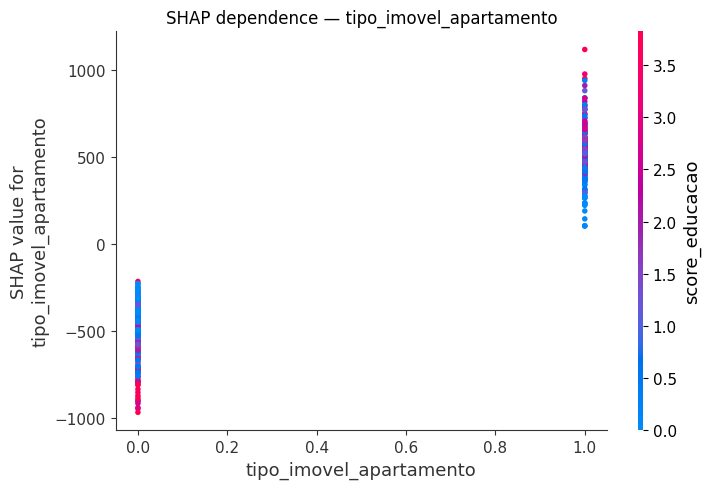

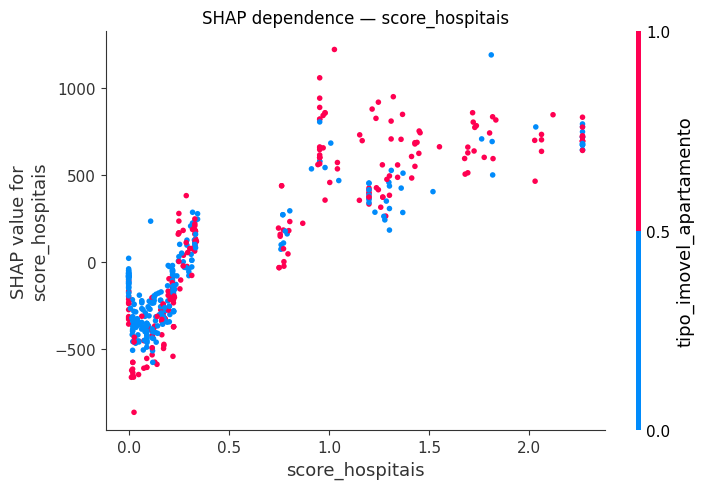

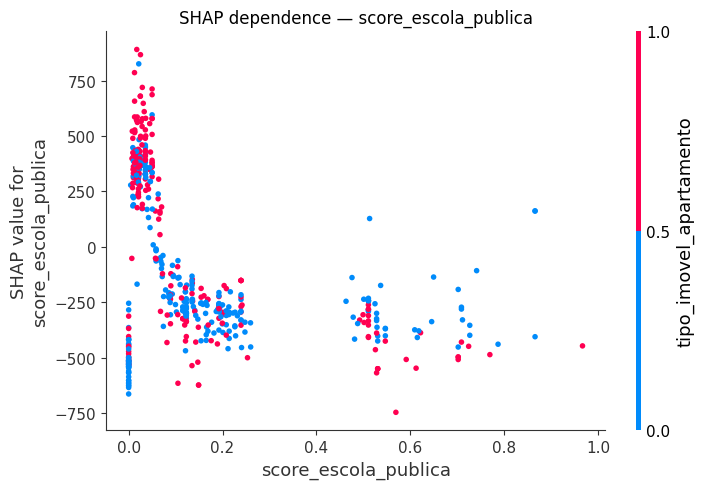

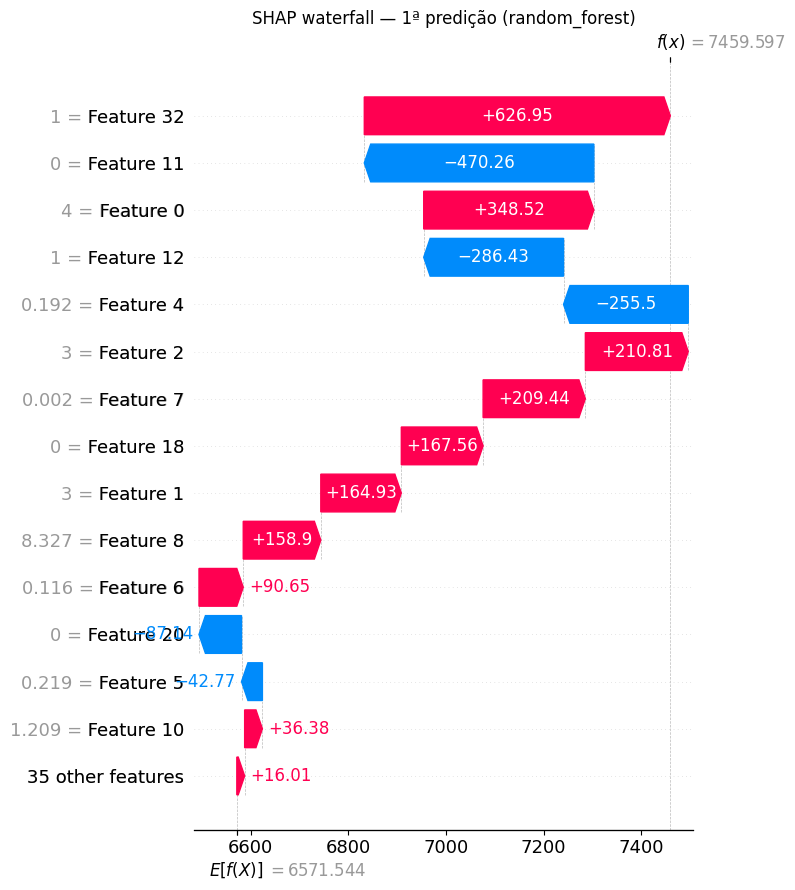

🏃 View run shap_random_forest at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/201525f3b6fc4c028fc20a0e6a162787
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604
Análise SHAP concluída e logada no MLflow.


In [38]:
# === Análise SHAP ===
import shap
from pathlib import Path
from tempfile import mkdtemp

# Seleciona o melhor modelo tree-based para SHAP (mais rápido)
MODELOS_TREE = {'random_forest', 'hist_gradient_boosting', 'lightgbm', 'catboost'}
N_BACKGROUND = 300
N_EXPLAIN = 500

tree_available = MODELOS_TREE & set(modelos_treinados.keys())
if tree_available:
    modelo_shap_nome = min(tree_available, key=lambda n: metricas_dict[n]['rmse'])
else:
    modelo_shap_nome = melhor_modelo

print(f'Modelo selecionado para SHAP: {modelo_shap_nome}')

pipeline = modelos_treinados[modelo_shap_nome]
modelo_shap = pipeline.named_steps['modelo']
preprocessor = pipeline.named_steps['preprocessador']

# Pré-processa X_test
X_test_pre = preprocessor.transform(X_test)

# Extrai nomes das features após transformação
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
nomes_features_shap = list(NUMERIC_FEATURES) + list(cat_feature_names)
print(f'Features: {len(nomes_features_shap)} ({len(NUMERIC_FEATURES)} num + {len(cat_feature_names)} cat)')
X_ex_shap = X_test_pre[:N_EXPLAIN] if len(X_test_pre) > N_EXPLAIN else X_test_pre
print(f'Features: {len(nomes_features_shap)}, amostras SHAP: {len(X_ex_shap)}')

# Computa SHAP values
if modelo_shap_nome in MODELOS_TREE:
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_ex_shap)
else:
    background = X_test_pre[:N_BACKGROUND]
    explainer = shap.PermutationExplainer(modelo_shap.predict, background)
    shap_values = explainer(X_ex_shap)

# Importância global (mean |SHAP|)
if shap_values.ndim == 3:
    shap_imp = np.abs(shap_values).mean(axis=(0, 1))
elif shap_values.ndim == 2:
    shap_imp = np.abs(shap_values).mean(axis=0)
else:
    shap_imp = np.abs(shap_values).mean(axis=0)

importancia_shap = pd.Series(shap_imp, index=nomes_features_shap).sort_values(ascending=False)
display(importancia_shap.head(20))

# --- Visualizações ---
tmpdir = Path(mkdtemp())

# 1. Summary beeswarm
shap.summary_plot(
    shap_values, X_ex_shap,
    feature_names=nomes_features_shap,
    show=False, max_display=20,
)
plt.title(f'SHAP — impacto por feature ({modelo_shap_nome})')
plt.tight_layout()
plt.savefig(tmpdir / f'shap_summary_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Bar plot
shap.summary_plot(
    shap_values, X_ex_shap,
    feature_names=nomes_features_shap,
    plot_type='bar', show=False, max_display=20,
)
plt.title(f'SHAP bar — impacto médio ({modelo_shap_nome})')
plt.tight_layout()
plt.savefig(tmpdir / f'shap_bar_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Dependence plot (top 3 features)
for feat in importancia_shap.index[:3]:
    shap.dependence_plot(
        feat, shap_values, X_ex_shap,
        feature_names=nomes_features_shap, show=False,
    )
    plt.title(f'SHAP dependence — {feat}')
    plt.tight_layout()
    plt.savefig(tmpdir / f'shap_dependence_{feat}_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
    plt.show()

# 4. Waterfall plot (first prediction)
if modelo_shap_nome in MODELOS_TREE:
    exp = explainer(X_ex_shap[:1])
    shap.waterfall_plot(exp[0], max_display=15, show=False)
    plt.title(f'SHAP waterfall — 1ª predição ({modelo_shap_nome})')
    plt.tight_layout()
    plt.savefig(tmpdir / f'shap_waterfall_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Log no MLflow
mlflow.start_run(run_name=f'shap_{modelo_shap_nome}', nested=True)
try:
    mlflow.set_tag('modelo_shap', modelo_shap_nome)
    for feat, imp in importancia_shap.head(30).items():
        mlflow.log_metric(f'shap_{feat}', float(imp))
    for f in tmpdir.glob('shap_*'):
        mlflow.log_artifact(str(f))
finally:
    mlflow.end_run()

print('Análise SHAP concluída e logada no MLflow.')


## Exemplos de previsão no conjunto de teste

In [40]:
features_list = [x.strip() for x in features[0].split(',')]
features_list

['banheiros',
 'vagas',
 'quartos',
 'score_escola_privada',
 'score_escola_publica',
 'score_hospitais',
 'score_mercado',
 'score_farmacia',
 'score_parque',
 'score_seguranca',
 'score_educacao',
 'tipo_imovel',
 'bairro']

In [42]:

melhor_modelo = metricas_df["rmse"].idxmin()
modelo_final = modelos_treinados[melhor_modelo]
pred_test = modelo_final.predict(X_test)

exemplos = pd_joinville.loc[X_test.index, features_list + [TARGET] + ["url"]
].copy()
exemplos["preco_previsto"] = pred_test.round(0).astype(int)
exemplos["erro_abs"] = (exemplos[f"{TARGET}"] - exemplos["preco_previsto"]).abs()
exemplos["erro_pct"] = (exemplos["erro_abs"] / exemplos[f"{TARGET}"] * 100).round(1)

exemplos.sort_values("erro_pct").tail(100)

,banheiros,vagas,quartos,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,score_educacao,tipo_imovel,bairro,preco_por_m2,url,preco_previsto,erro_abs,erro_pct
1648,2,0,3,0.371665,0.078875,0.203019,2.089647,0.078151,21.823707,0.450323,0.355890,casa,floresta,1967.105263,https://www.zapimoveis.com.br/imovel/venda-cas...,4865,2897.894737,147.3
25075,2,0,3,0.063264,0.512700,0.035185,0.050568,0.011256,2.186292,0.456661,-0.039276,casa,vila nova,1962.151394,https://sc.olx.com.br/norte-de-santa-catarina/...,4914,2951.848606,150.4
8079,4,0,3,0.496352,0.122887,0.090348,0.711936,0.193922,41.926023,1.392686,0.471775,casa,floresta,1964.285714,https://www.chavesnamao.com.br/imovel/casa-a-v...,4923,2958.714286,150.6
6224,0,0,0,2.079147,0.088383,0.334196,0.254943,0.099242,9.508483,0.670594,2.061471,terreno,bucarein,1006.006006,https://www.chavesnamao.com.br/imovel/terreno-...,2579,1572.993994,156.4
5647,0,0,0,0.412770,0.510938,0.223607,1.274802,0.207438,3.259807,0.333690,0.310583,terreno,costa e silva,732.954545,https://www.chavesnamao.com.br/imovel/terreno-...,1894,1161.045455,158.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,2,2,4,0.052035,0.054975,0.081028,0.062401,0.000848,0.130733,0.285089,0.041040,rural,pirabeiraba,210.000000,https://www.vivareal.com.br/imovel/fazenda---s...,3788,3578.000000,1703.8
25593,1,0,1,0.378215,0.149957,0.291746,0.145477,0.053432,7.291150,0.567817,0.348224,casa,pirabeiraba,233.333333,https://sc.olx.com.br/norte-de-santa-catarina/...,5091,4857.666667,2081.9
2172,5,3,4,3.919260,0.019850,1.469859,0.232573,0.794923,25.173699,1.853151,3.915290,apartamento,anita garibaldi,458.000000,https://www.vivareal.com.br/imovel/apartamento...,11478,11020.000000,2406.1
906,0,0,0,0.187717,0.560069,0.020124,0.740458,0.096908,3.318586,1.111478,0.075703,terreno,vila nova,112.533554,https://www.zapimoveis.com.br/imovel/venda-ter...,3854,3741.466446,3324.8


In [64]:
faixas_erro = [0, 10, 20, 30, 50, 100, np.inf]
valor_acumulado = 0
for i in range(len(faixas_erro)-1):
    lower = faixas_erro[i]
    upper = faixas_erro[i+1]
    count_in_faixa = exemplos[(exemplos['erro_pct'] > lower) & (exemplos['erro_pct'] <= upper)].shape[0]
    pct_in_faixa = count_in_faixa / exemplos.shape[0] * 100
    valor_acumulado += pct_in_faixa
    print(f"Erro entre {lower}% e {upper}%: {count_in_faixa} exemplos ({pct_in_faixa:.1f}%) | Acumulado: {valor_acumulado:.1f}%")
print(f"Total acumulado: {valor_acumulado:.1f}%")

Erro entre 0% e 10%: 925 exemplos (34.8%) | Acumulado: 34.8%
Erro entre 10% e 20%: 657 exemplos (24.7%) | Acumulado: 59.5%
Erro entre 20% e 30%: 360 exemplos (13.5%) | Acumulado: 73.1%
Erro entre 30% e 50%: 344 exemplos (12.9%) | Acumulado: 86.0%
Erro entre 50% e 100%: 205 exemplos (7.7%) | Acumulado: 93.8%
Erro entre 100% e inf%: 164 exemplos (6.2%) | Acumulado: 99.9%
Total acumulado: 99.9%


In [74]:
dados_bairro = exemplos[exemplos['bairro'].isin(['centro'])].sort_values("erro_pct").tail(50)
for i in range(50):
    print(dados_bairro.iloc[i]['url'])
    print(f"Bairro: {dados_bairro.iloc[i]['bairro']} | Tipo: {dados_bairro.iloc[i]['tipo_imovel']}")
    print(f"Valor real: R$ {dados_bairro.iloc[i][TARGET]:,.0f} | Previsto: R$ {dados_bairro.iloc[i]['preco_previsto']:,.0f} | Erro: {dados_bairro.iloc[i]['erro_pct']}%")


https://www.chavesnamao.com.br/imovel/cobertura-a-venda-3-quartos-com-garagem-sc-joinville-centro-RS1349900/id-28124929/
Bairro: centro | Tipo: apartamento
Valor real: R$ 10,886 | Previsto: R$ 9,471 | Erro: 13.0%
https://www.chavesnamao.com.br/imovel/predio-a-venda-5-salas-sc-joinville-centro-945m2-RS6300000/id-41334310/
Bairro: centro | Tipo: outros
Valor real: R$ 6,667 | Previsto: R$ 7,572 | Erro: 13.6%
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-sc-joinville-centro-97m2-RS547666/id-41313867/
Bairro: centro | Tipo: apartamento
Valor real: R$ 10,142 | Previsto: R$ 8,756 | Erro: 13.7%
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/wp6904-apartamento-duplex-no-high-line-park-1472952997
Bairro: centro | Tipo: apartamento
Valor real: R$ 7,971 | Previsto: R$ 9,065 | Erro: 13.7%
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/flat-no-centro-de-joinville-mobiliado-1441880420
Bairro: centro | Tipo: apartamento
Valor real: R$ 8,667 | Previsto: R$ 9,882 | Erro: 14.0%


In [51]:
grouped_preco_previsto_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"preco_previsto": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "preco_por_m2": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"), ascending=False).head(20).plot()

<Axes: xlabel='bairro,tipo_imovel'>

In [52]:
grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"))

preco_previsto           preco_por_m2  \
                                        mean   median          mean   
bairro         tipo_imovel                                            
santa catarina terreno            746.600000    632.0    669.331010   
itinga         terreno            753.000000    668.0    931.536738   
rio bonito     terreno            837.000000    837.0    380.733945   
jardim sofia   terreno            914.000000    914.0    404.151741   
boehmerwald    terreno            984.000000    915.0    663.860489   
...                                      ...      ...           ...   
centro         apartamento      10222.792208  10072.0  10388.133149   
america        apartamento      10181.762887  10186.5  10836.578348   
gloria         predio_inteiro   10225.000000  10225.0  14475.000000   
vila nova      rural            10529.000000  10529.0  42857.142857   
atiradores     outros           10630.000000  10630.0   7505.639098   

                                             
                                     median  
bairro         tipo_imovel                   
santa catarina terreno           822.368421  
itinga         terreno           940.860215  
rio bonito     terreno           380.733945  
jardim sofia   terreno           404.151741  
boehmerwald    terreno           638.888889  
...                                     ...  
centro         apartamento     10127.631579  
america        apartamento     10592.898230  
gloria         predio_inteiro  14475.000000  
vila nova      rural           42857.142857  
atiradores     outros           7505.639098  

[149 rows x 4 columns]

In [46]:
grouped_erro_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"erro_pct": ["mean", "median"]})#.sort_values("erro_pct", ascending=False)

grouped_erro_bairro.sort_values(("erro_pct", "median"), ascending=True).head(20).plot(kind="barh", figsize=(10, 6), title="Erro percentual médio por bairro")

<Axes: title={'center': 'Erro percentual médio por bairro'}, ylabel='bairro,tipo_imovel'>

In [ ]:
bairros = df_modelo["bairro"].unique()
tipos = df_modelo["tipo_imovel"].unique()

tipos = ["apartamento"]  # Foco nos tipos mais comuns para evitar ruído de poucos exemplos

metrics_bairro = {}

for bairro in bairros:
    for tipo in tipos:
        try:
            print(f"{bairro} - {tipo} - Métricas por bairro:")
            previsao_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"preco_previsto"]
            valor_verdadeiro_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"{TARGET}"]
            metrics_bairro[(bairro, tipo)] = metricas(bairro, valor_verdadeiro_bairro, previsao_bairro)
        except Exception as e:
            print(f"Erro ao processar o bairro {bairro}: {e}")
    

In [57]:
metrics_bairro_df = pd.DataFrame(metrics_bairro).T.sort_values("mape", ascending=True)
metrics_bairro_df.head(40)

,,rmse,mae,mape,r2
santa catarina,apartamento,617.864267,501.575561,8.693306,0.581467
itinga,apartamento,485.196078,485.196078,10.758696,NaN
parque guarani,apartamento,491.000000,491.000000,11.222857,NaN
petropolis,apartamento,747.914652,623.474731,11.424782,-0.222620
distrito industrial,apartamento,644.733333,644.733333,12.048238,NaN
nova brasilia,apartamento,793.501192,669.135642,12.691585,-0.527009
iririu,apartamento,1008.933443,776.557604,12.976444,0.286221
jardim iririu,apartamento,952.005171,675.293146,13.869601,-0.528936
boehmerwald,apartamento,830.511519,652.805538,14.056076,-1.898417
jarivatuba,apartamento,811.777130,774.541712,14.956856,-0.203555


# Treinando o melhor modelo com todos os dados e fazendo a predicao

In [225]:
def treinar_pipeline_final(nome, estimador, X_tr, y_tr):
    pipe = Pipeline([
        ("preprocessador", criar_preprocessador()),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe

In [229]:
import numpy as np
import pandas as pd
from typing import Tuple

def clean_target(X, y, max_abs_value: float = 1e200) -> Tuple:
    """Limpa y removendo NaN e Inf e alinha X com y.

    - Converte y para Series numérica (coerce errors -> NaN).
    - Marca valores NaN, Inf ou abs(y) > max_abs_value como inválidos.
    - Remove as linhas correspondentes em X e y mantendo tipo de X (np.ndarray or pd.DataFrame).

    Retorna: X_clean, y_clean
    """
    # preparar y
    y_ser = pd.to_numeric(pd.Series(y).copy(), errors="coerce")

    # preparar X para alinhamento (converter em DataFrame temporariamente)
    X_is_df = isinstance(X, pd.DataFrame)
    try:
        X_df = X.copy() if X_is_df else pd.DataFrame(X)
    except Exception:
        X_df = pd.DataFrame(np.asarray(X))

    # alinhar índices: use interseção de índices se possível
    common_index = X_df.index.intersection(y_ser.index)
    if len(common_index) == 0:
        min_len = min(len(X_df), len(y_ser))
        if len(X_df) != len(y_ser):
            print(f"clean_target: índices diferentes, truncando X/y para {min_len}")
        X_df = X_df.iloc[:min_len].copy()
        y_ser = y_ser.iloc[:min_len].copy()
    else:
        X_df = X_df.loc[common_index].copy()
        y_ser = y_ser.loc[common_index].copy()

    # detectar infinitos e valores absurdos após alinhamento
    bad_mask = y_ser.isna() | np.isinf(y_ser) | (y_ser.abs() > max_abs_value)
    n_bad = int(bad_mask.sum())
    if n_bad > 0:
        print(f"clean_target: removendo {n_bad} observações com NaN/Inf/valores extremos de y")

    keep_mask = ~bad_mask
    X_clean = X_df.loc[keep_mask].copy()
    y_clean = y_ser.loc[keep_mask].copy().reset_index(drop=True)

    # devolver no mesmo tipo de X
    if not X_is_df:
        X_out = X_clean.values
    else:
        X_out = X_clean

    return X_out, y_clean


In [163]:
columns = [TARGET] + NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [237]:
pd_joinville_limpo = pd_joinville[features_list + [TARGET]].dropna()
joinville_completo = pd_joinville_limpo.copy()
X_joinville_completo = joinville_completo[features_list].copy()
y_joinville_completo = joinville_completo[TARGET].copy()

melhor_modelo = metricas_df["rmse"].idxmin()
melhor_modelo

'random_forest'

In [238]:
X_joinville_completo, y_joinville_completo = clean_target(X_joinville_completo, y_joinville_completo)

clean_target: removendo 12 observações com NaN/Inf/valores extremos de y


In [240]:
X_joinville_completo.shape, y_joinville_completo.shape

((26840, 13), (26840,))

In [241]:
modelo_final = treinar_pipeline_final("modelo_final", best_models[melhor_modelo], X_joinville_completo, y_joinville_completo)   

In [270]:
pd_joinville.columns

Index(['url', 'titulo', 'metragem', 'banheiros', 'vagas', 'quartos',
       'valor_imovel', 'condominio', 'endereco', 'iptu', 'descricao',
       'data_criacao', 'caracteristicas', 'fotos', 'link_maps', 'fonte', 'rua',
       'numero', 'bairro', 'cidade', 'estado', 'cep', 'dias_publicacao',
       'tipo_imovel', 'lat', 'lng', 'preco_por_m2', 'faixa', 'p25_bairro',
       'p50_bairro', 'p75_bairro', 'desvio_mediana', 'score_escola_privada',
       'score_escola_publica', 'score_hospitais', 'score_mercado',
       'score_farmacia', 'score_parque', 'score_seguranca', 'score_educacao'],
      dtype='object')

In [ ]:
dados_completo_final = X_joinville_completo.copy()

predicao_completa= modelo_final.predict(X_joinville_completo)
dados_completo_final["predicao_metro_quadrado"] = predicao_completa.round(0).astype(int)

dados_completo_final['url'] = pd_joinville.loc[X_joinville_completo.index, 'url']
dados_completo_final['metragem'] = pd_joinville.loc[X_joinville_completo.index, 'metragem']
dados_completo_final['valor_imovel'] = pd_joinville.loc[X_joinville_completo.index, 'valor_imovel']
dados_completo_final['valor_imovel_previsto'] = dados_completo_final['metragem'] * dados_completo_final['predicao_metro_quadrado']

dados_completo_final['metro_quadrado_real'] = dados_completo_final['valor_imovel'] /dados_completo_final['metragem']


dados_completo_final["erro_abs"] = (dados_completo_final["metro_quadrado_real"] - dados_completo_final["predicao_metro_quadrado"]).abs()
dados_completo_final["erro_pct"] = (dados_completo_final["erro_abs"] / dados_completo_final["metro_quadrado_real"] * 100).round(1)



dados_completo_final.sort_values("erro_pct")



In [296]:
apartamentos = dados_completo_final[dados_completo_final["tipo_imovel"] == "apartamento"].dropna().sort_values("erro_pct")

In [298]:
apartamentos_limite = apartamentos[apartamentos['erro_pct'] < 100]
for i in range(len(apartamentos_limite)):
    print("---")
    print(apartamentos_limite.iloc[i]['url'])
    print(f"Bairro: {apartamentos_limite.iloc[i]['bairro']} | Tipo: {apartamentos_limite.iloc[i]['tipo_imovel']}")
    print(f"Valor real: R$ {apartamentos_limite.iloc[i]["metro_quadrado_real"]} | Previsto: R$ {apartamentos_limite.iloc[i]['predicao_metro_quadrado']} | Erro: {apartamentos_limite.iloc[i]['erro_pct']}%")
    print(f"Valor do imovel real: R$ {apartamentos_limite.iloc[i]["valor_imovel"]} | Previsto: R$ {apartamentos_limite.iloc[i]['valor_imovel_previsto']} |")
    print(f"Metragem {apartamentos_limite.iloc[i]['metragem']} ")
    print("---")

---
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-semi-mobiliado-2-quartos-aventureiro-1477490378
Bairro: aventureiro | Tipo: apartamento
Valor real: R$ 5800.0 | Previsto: R$ 5802 | Erro: 0.0%
Valor do imovel real: R$ 290000.0 | Previsto: R$ 290100.0 |
Metragem 50.0 
---
---
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-itaum-48m2-RS301359/id-41796793/
Bairro: itaum | Tipo: apartamento
Valor real: R$ 6278.3125 | Previsto: R$ 6280 | Erro: 0.0%
Valor do imovel real: R$ 301359.0 | Previsto: R$ 301440.0 |
Metragem 48.0 
---
---
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-em-rua-expedicionario-holz-atiradores-joinville-sc-1498499462
Bairro: atiradores | Tipo: apartamento
Valor real: R$ 10983.730964467006 | Previsto: R$ 10979 | Erro: 0.0%
Valor do imovel real: R$ 2163795.0 | Previsto: R$ 2162863.0 |
Metragem 197.0 
---
---
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc

In [292]:
faixas_erro = [0, 10, 20, 30, 50, 100, np.inf]
valor_acumulado = 0
for i in range(len(faixas_erro)-1):
    lower = faixas_erro[i]
    upper = faixas_erro[i+1]
    count_in_faixa = apartamentos[(apartamentos['erro_pct'] > lower) & (apartamentos['erro_pct'] <= upper)].shape[0]
    pct_in_faixa = count_in_faixa / apartamentos.shape[0] * 100
    valor_acumulado += pct_in_faixa
    print(f"Erro entre {lower}% e {upper}%: {count_in_faixa} exemplos ({pct_in_faixa:.1f}%) | Acumulado: {valor_acumulado:.1f}%")
print(f"Total acumulado: {valor_acumulado:.1f}%")

Erro entre 0% e 10%: 4965 exemplos (42.3%) | Acumulado: 42.3%
Erro entre 10% e 20%: 3131 exemplos (26.7%) | Acumulado: 68.9%
Erro entre 20% e 30%: 1581 exemplos (13.5%) | Acumulado: 82.4%
Erro entre 30% e 50%: 1116 exemplos (9.5%) | Acumulado: 91.9%
Erro entre 50% e 100%: 625 exemplos (5.3%) | Acumulado: 97.2%
Erro entre 100% e inf%: 299 exemplos (2.5%) | Acumulado: 99.8%
Total acumulado: 99.8%


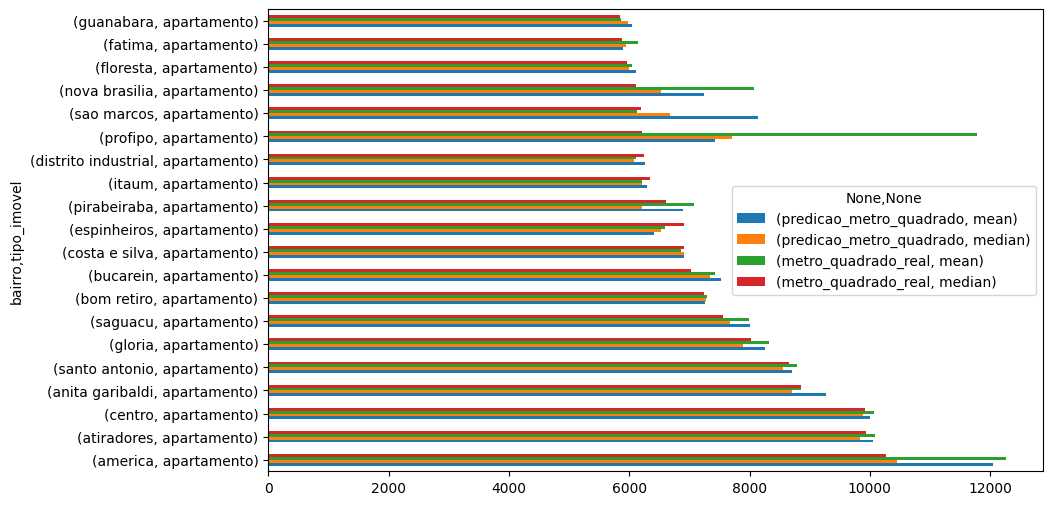

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
grouped_preco_previsto_bairro = apartamentos.groupby(["bairro", "tipo_imovel"]).aggregate({"predicao_metro_quadrado": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "metro_quadrado_real": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("metro_quadrado_real", "median"), ascending=False).head(20).plot(kind="barh", figsize=(10, 6),)
plt.show()

In [308]:
grouped_preco_previsto_bairro.sort_values(("metro_quadrado_real", "median"), ascending=False)

predicao_metro_quadrado           \
                                                   mean   median   
bairro              tipo_imovel                                    
america             apartamento            12045.942512  10455.0   
atiradores          apartamento            10056.085479   9836.0   
centro              apartamento            10009.741543   9885.0   
anita garibaldi     apartamento             9276.360248   8704.0   
santo antonio       apartamento             8709.381679   8556.0   
gloria              apartamento             8256.343874   7895.0   
saguacu             apartamento             8005.535211   7671.0   
bom retiro          apartamento             7263.794118   7276.0   
bucarein            apartamento             7519.372624   7349.0   
costa e silva       apartamento             6907.096883   6907.0   
espinheiros         apartamento             6411.428571   6532.0   
pirabeiraba         apartamento             6901.661290   6216.0   
itaum               apartamento             6292.583333   6218.0   
distrito industrial apartamento             6254.653846   6078.0   
profipo             apartamento             7431.666667   7713.0   
sao marcos          apartamento             8146.194444   6686.0   
nova brasilia       apartamento             7247.323529   6527.0   
floresta            apartamento             6106.509302   6000.0   
fatima              apartamento             5898.653061   5952.0   
guanabara           apartamento             6049.744681   5985.5   
iririu              apartamento             5852.010870   5738.0   
petropolis          apartamento             6035.235294   5981.5   
jardim sofia        apartamento             5785.692308   5633.5   
aventureiro         apartamento             5678.411392   5634.0   
vila nova           apartamento             5829.685714   5715.0   
comasa              apartamento             5928.847826   5944.0   
boa vista           apartamento             5883.706667   5628.0   
joao costa          apartamento             5102.873786   5175.0   
jardim iririu       apartamento             5456.966102   5451.0   
santa catarina      apartamento             5333.677419   5055.0   
parque guarani      apartamento             5243.600000   4761.0   
jarivatuba          apartamento             9866.450000   5516.0   
adhemar garcia      apartamento             4787.307692   4720.0   
itinga              apartamento             4571.333333   4697.0   
boehmerwald         apartamento             6597.289474   7398.0   
morro do meio       apartamento             4837.666667   4796.0   
paranaguamirim      apartamento             4699.037037   4570.0   
jardim paraiso      apartamento             4380.714286   3885.0   
ulysses guimaraes   apartamento             3763.000000   3763.0   

                                metro_quadrado_real                
                                               mean        median  
bairro              tipo_imovel                                    
america             apartamento        12267.025924  10275.366013  
atiradores          apartamento        10078.935257   9941.230159  
centro              apartamento        10067.933771   9913.419913  
anita garibaldi     apartamento         8863.188895   8857.142857  
santo antonio       apartamento         8783.558639   8648.648649  
gloria              apartamento         8316.829160   8031.007107  
saguacu             apartamento         7991.392683   7555.555556  
bom retiro          apartamento         7292.123754   7247.237392  
bucarein            apartamento         7421.535426   7032.758621  
costa e silva       apartamento         6863.936072   6917.261538  
espinheiros         apartamento         6601.622942   6909.625000  
pirabeiraba         apartamento         7080.322685   6614.979167  
itaum               apartamento         6216.789955   6340.744681  
distrito industrial apartamento         6110.577796   6252.062802  
profipo            